# Data Analysis Process :

## 1- Asking Right Questions

## 2- Data Wrangling
* ### Data Gathering
* ### Data Assessing
* ### Data Cleaning

## 3- Exploratory Data Analysis

## 4- Drawing conclusion

## 5- Communicating Results


## Summary of this session :
* ### You have to become detective
* ### Will try to create a framework
* ### Frameworks may vary
* ### The goal is to give you idea

## Data Wrangling
* ### Data Gathering
* ### Data Accessing
* ### Data Cleaning

# Data Assessing
* ### In this step, the data is to be understood more deeply. Before implementing methods to clean it, you will definitely need to have a better idea about what the data is about

## Types of Unclean Data :
### There are 2 kinds of unclean data -
## 1- Dirty Data ( Data with Quality issues ) : Low quality data. Low Quality data has content issues but structurally it is correct.
- ### Duplicated Data
- ### Missing Data
- ### Corrupt Data
- ### Inaccurate Data

## 2- Messy Data ( Data with tidiness issues ) : Messy data, also known as UnTidy data. UnTidy data has structural issues. Tidy data(structural data) has the following properties that Untidy data doesn't follow:
- ### Each variable forms a column
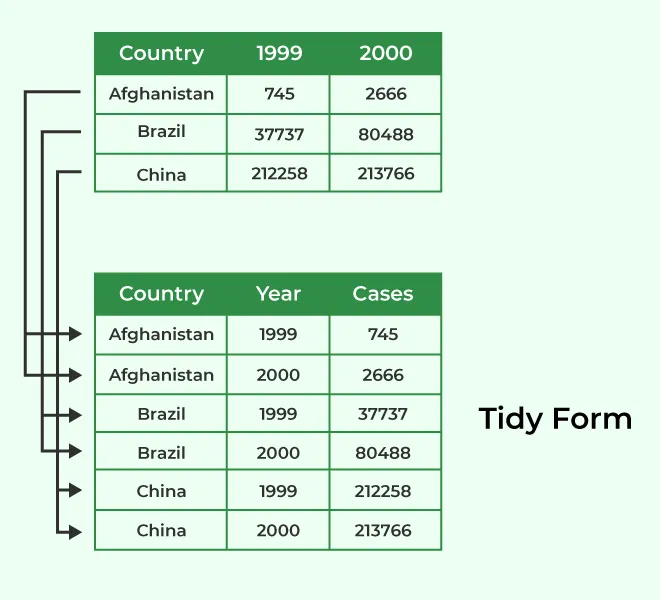
- ### Each observation forms a row : No single data in another rows
- ### Each observational unit forms a table : No need for unnecessary tables


In [1]:
import pandas as pd
import numpy as np

In [44]:
patients = pd.read_csv('/content/drive/MyDrive/DSMP Datasets colab/Data accessing and cleaning/patients.csv')
treatments = pd.read_csv('/content/drive/MyDrive/DSMP Datasets colab/Data accessing and cleaning/treatments.csv')
adverse_reactions = pd.read_csv('/content/drive/MyDrive/DSMP Datasets colab/Data accessing and cleaning/adverse_reactions.csv')
treatments_cut = pd.read_csv('/content/drive/MyDrive/DSMP Datasets colab/Data accessing and cleaning/treatments_cut.csv')

In [3]:
# view datasets
patients.head()

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi
0,1,female,Zoe,Wellish,576 Brown Bear Drive,Rancho California,California,92390.0,United States,951-719-9170ZoeWellish@superrito.com,7/10/1976,121.7,66,19.6
1,2,female,Pamela,Hill,2370 University Hill Road,Armstrong,Illinois,61812.0,United States,PamelaSHill@cuvox.de+1 (217) 569-3204,4/3/1967,118.8,66,19.2
2,3,male,Jae,Debord,1493 Poling Farm Road,York,Nebraska,68467.0,United States,402-363-6804JaeMDebord@gustr.com,2/19/1980,177.8,71,24.8
3,4,male,Liêm,Phan,2335 Webster Street,Woodbridge,NJ,7095.0,United States,PhanBaLiem@jourrapide.com+1 (732) 636-8246,7/26/1951,220.9,70,31.7
4,5,male,Tim,Neudorf,1428 Turkey Pen Lane,Dothan,AL,36303.0,United States,334-515-7487TimNeudorf@cuvox.de,2/18/1928,192.3,27,26.1


In [4]:
treatments.head()

,given_name,surname,auralin,novodra,hba1c_start,hba1c_end,hba1c_change
0,veronika,jindrová,41u - 48u,-,7.63,7.20,NaN
1,elliot,richardson,-,40u - 45u,7.56,7.09,0.97
2,yukitaka,takenaka,-,39u - 36u,7.68,7.25,NaN
3,skye,gormanston,33u - 36u,-,7.97,7.62,0.35
4,alissa,montez,-,33u - 29u,7.78,7.46,0.32


In [5]:
treatments_cut.head()

,given_name,surname,auralin,novodra,hba1c_start,hba1c_end,hba1c_change
0,jožka,resanovič,22u - 30u,-,7.56,7.22,0.34
1,inunnguaq,heilmann,57u - 67u,-,7.85,7.45,NaN
2,alwin,svensson,36u - 39u,-,7.78,7.34,NaN
3,thể,lương,-,61u - 64u,7.64,7.22,0.92
4,amanda,ribeiro,36u - 44u,-,7.85,7.47,0.38


In [6]:
adverse_reactions.head()

,given_name,surname,adverse_reaction
0,berta,napolitani,injection site discomfort
1,lena,baer,hypoglycemia
2,joseph,day,hypoglycemia
3,flavia,fiorentino,cough
4,manouck,wubbels,throat irritation


## Step-1- Write a Summary of your data
### ✅ This is a Datset about 500 patients of which 350 patients participated in a clinical trial. None of the patients were using **Novodra**( a popular injectable insulin ) or **Auralin** ( the oral insulin being researched ) as their primary source of insulin before. All were experiencing elevated 'HbA1c' levels.

### ✅ All 350 patients were treated with Novodra to establish a baseline 'HbA1c' level and insulin dose. After 4 weeks, which isn't enough time to capture all the change in HbA1c that can be attributed by the switch to Auralin or Novodra :
* ### 175 patients switched to Auralin for 24 weeks
* ### 175 patients continued using Novodra for 24 weeks

## ▶ Data about patients feeling some adverse effects is also recorded

## Step-2- Write Column descriptions

### Table -> adverse_reactions
* ### given_name : the given name of eacg patient in the Master Patient Index that took part in the clinical trial and had an adverse reaction ( includes both patients treated Auralin and Novodra )
* ### surname : the surname of each patient in the Master Patient Index that took part in the clinical trial and had an adverse reaction ( includes both patients treated with Auralin and Novodra )
* ### adverse_reaction : the adverse reaction reported by the patient

## Step-3- Add any additional information
### Additional useful information:
* ### Insulin resistance varies person to person, which is why both 'starting median daily dose' and 'ending median daily dose' are required, i.e. to calculate change in dose.
* ### It is important to test drugs and medical products in the people they are meant to help. People of different age, race, sex and ethnic group must be included in clinical trials. This diversity is reflected in the 'patients' table.

# Types of Assessment
## There are 2 types of assessment styles
* ### Manual - Looking through the data manually with naked eyes
* ### Programmatic - By using pandas functions such as info() , describe() or sample()

# Steps in Assessment
## There are 2 steps involved in Assessment
* ### Step-1- Discover
* ### Step-2- Document

In [41]:
# extract data for manual assessment in excel sheets using 'pd.ExcelWriter()' function

with pd.ExcelWriter('clinicial_trials.xlsx') as writer:
  patients.to_excel(writer , sheet_name = 'patients')
  treatments.to_excel(writer , sheet_name = 'treatments')
  treatments_cut.to_excel(writer , sheet_name = 'treatment_cut')
  adverse_reactions.to_excel(writer , sheet_name = 'adverse_reactions')

# Manual Assessment

# Issues with the Dataset
## 1. Dirty Data

Table - `patients`
- patient_id = 9 has misspelled name ' - `accuracy`
- 'state' column sometimees contain full name and some times abbreviation - `consistency`
- 'zip code' colummn has entries with '4 digit' somewhere - `validity`
- Data missing for 12 patients in address, city, state, zip-code, country and contact columns - `completion`
- Incorrect Datatype for - assigned_sex(ibject -> categorical) , zip-code(float64 -> int64) and birthdate( object -> datetime64) - `validity`
- Duplicate entries by the name of 'john Doe' - `accuracy`
- 1 patient has weight = 48 pounds ( patient_id = 211 ) - `accuracy`
- 1 pateint has height = 27 inches ( patient_id = 5 ) - `accuracy`


Table - `treatments` & `treatments_cut`
- 'given_name' and 'surname' columns is all lower case - `consistency`
- remove 'u' from Auralin and Novodra column - `validity`
- '-' values in Auralin and Novodra column should be treated as 'NaN' - `validity`
- missing values in 'hba1c_change' column - `completion`
- 1 duplicate entry by the name 'joseph day' in 'treatments' column - `accuracy`
- in 'hba1c_change' column, values are starting from 0.9 but should start from 0.4 as the substraction done on 'hba1c_start' and 'hba1c_end' id wrong - `accuracy`

Table - `adverse_reactions`
- 'given_name' and 'surname' are all should be in lower case - `consistency`

## 2. Messy Data
Table - `patients`
- 'contact' column contains both phone and email

Table - `treatments` and `treatments_cut`
- 'Auralin' and 'Novodra' columns should be splitted into 2 columns 'start dose' and 'end dose'
- merge both the tables

Table - `adverse_reactions`
- This table should not exist independently coz 'adverse_reaction' column from this table can be shifted to 'treatments' table

# Automatic Assessment

### Following functions you can start with :
* ### head and tail
* ### sample
* ### info
* ### isnull
* ### duplicated
* ### describe

### head() and tail()

In [8]:
# head() / tail() - to check data relevancy in upper and lower rows
patients.head()
patients.tail()

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi
498,499,male,Mustafa,Lindström,2530 Victoria Court,Milton Mills,ME,3852.0,United States,207-477-0579MustafaLindstrom@jourrapide.com,4/10/1959,181.1,72,24.6
499,500,male,Ruman,Bisliev,494 Clarksburg Park Road,Sedona,AZ,86341.0,United States,928-284-4492RumanBisliev@gustr.com,3/26/1948,239.6,70,34.4
500,501,female,Jinke,de Keizer,649 Nutter Street,Overland Park,MO,64110.0,United States,816-223-6007JinkedeKeizer@teleworm.us,1/13/1971,171.2,67,26.8
501,502,female,Chidalu,Onyekaozulu,3652 Boone Crockett Lane,Seattle,WA,98109.0,United States,ChidaluOnyekaozulu@jourrapide.com1 360 443 2060,2/13/1952,176.9,67,27.7
502,503,male,Pat,Gersten,2778 North Avenue,Burr,Nebraska,68324.0,United States,PatrickGersten@rhyta.com402-848-4923,5/3/1954,138.2,71,19.3


### sample()

In [9]:
# sample() - to check random data 10-15 times
display(patients.sample())
display(patients.sample())
display(patients.sample())
display(patients.sample())
display(patients.sample())
display(patients.sample())
display(patients.sample())
display(patients.sample())
display(patients.sample())
display(patients.sample())

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi
484,485,male,Placido,Udinesi,1094 Jones Avenue,Greensboro,NC,28716.0,United States,336-697-2005PlacidoUdinesi@dayrep.com,5/31/1934,175.8,65,29.3


,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi
502,503,male,Pat,Gersten,2778 North Avenue,Burr,Nebraska,68324.0,United States,PatrickGersten@rhyta.com402-848-4923,5/3/1954,138.2,71,19.3


,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi
115,116,female,Caroline,Bois,1350 Meadow Lane,Lakeport,California,95453.0,United States,CarolineBois@rhyta.com1 707 262 6503,12/26/1985,151.4,64,26.0


,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi
125,126,female,Seweryna,Czerwinska,36 Heather Sees Way,Tulsa,OK,74119.0,United States,918-714-7543SewerynaCzerwinska@jourrapide.com,6/30/1982,203.5,63,36.0


,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi
63,64,male,Yukitaka,Takenaka,1975 Holden Street,San Diego,California,92103.0,United States,619-299-1495YukitakaTakenaka@einrot.com,11/24/1944,193.2,72,26.2


,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi
270,271,female,Jowita,Wiśniewska,2168 Butternut Lane,Granite City,Illinois,62040.0,United States,JowitaWisniewska@armyspy.com+1 (618) 512-3319,11/8/1934,108.1,61,20.4


,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi
153,154,male,John,Carreiro,1463 Martha Ellen Drive,Reno,NV,89509.0,United States,JohnACarreiro@superrito.com1 775 770 7827,4/8/1976,177.8,68,27.0


,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi
433,434,male,Leo,Vieira,4894 Chandler Hollow Road,Pittsburgh,PA,15215.0,United States,412-449-0733LeoDVieira@cuvox.de,3/9/1975,154.4,71,21.5


,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi
383,384,male,Torben,Mortensen,4682 Science Center Drive,Monteview,ID,83435.0,United States,TorbenMMortensen@einrot.com1 208 657 2473,7/24/1943,168.7,69,24.9


,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi
161,162,male,Mitsunobu,Fujiwara,212 Tibbs Avenue,Chester,MT,59522.0,United States,406-759-6160MitsunobuFujiwara@armyspy.com,5/21/1969,223.5,67,35.0


### info()

In [10]:
# info() - broader view of data - total entries, total columns with names, Non-Null counts, Data Type of column, memory usage of table
patients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 503 entries, 0 to 502
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   patient_id    503 non-null    int64  
 1   assigned_sex  503 non-null    object 
 2   given_name    503 non-null    object 
 3   surname       503 non-null    object 
 4   address       491 non-null    object 
 5   city          491 non-null    object 
 6   state         491 non-null    object 
 7   zip_code      491 non-null    float64
 8   country       491 non-null    object 
 9   contact       491 non-null    object 
 10  birthdate     503 non-null    object 
 11  weight        503 non-null    float64
 12  height        503 non-null    int64  
 13  bmi           503 non-null    float64
dtypes: float64(3), int64(2), object(9)
memory usage: 55.1+ KB


In [11]:
treatments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 280 entries, 0 to 279
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   given_name    280 non-null    object 
 1   surname       280 non-null    object 
 2   auralin       280 non-null    object 
 3   novodra       280 non-null    object 
 4   hba1c_start   280 non-null    float64
 5   hba1c_end     280 non-null    float64
 6   hba1c_change  171 non-null    float64
dtypes: float64(3), object(4)
memory usage: 15.4+ KB


In [12]:
treatments_cut.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70 entries, 0 to 69
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   given_name    70 non-null     object 
 1   surname       70 non-null     object 
 2   auralin       70 non-null     object 
 3   novodra       70 non-null     object 
 4   hba1c_start   70 non-null     float64
 5   hba1c_end     70 non-null     float64
 6   hba1c_change  42 non-null     float64
dtypes: float64(3), object(4)
memory usage: 4.0+ KB


In [13]:
adverse_reactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   given_name        34 non-null     object
 1   surname           34 non-null     object
 2   adverse_reaction  34 non-null     object
dtypes: object(3)
memory usage: 948.0+ bytes


### Isnull()

In [14]:
# isnull() - to check missing values
patients[patients['address'].isnull()]

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi
209,210,female,Lalita,Eldarkhanov,NaN,NaN,NaN,NaN,NaN,NaN,8/14/1950,143.4,62,26.2
219,220,male,Mỹ,Quynh,NaN,NaN,NaN,NaN,NaN,NaN,4/9/1978,237.8,69,35.1
230,231,female,Elisabeth,Knudsen,NaN,NaN,NaN,NaN,NaN,NaN,9/23/1976,165.9,63,29.4
234,235,female,Martina,Tománková,NaN,NaN,NaN,NaN,NaN,NaN,4/7/1936,199.5,65,33.2
242,243,male,John,O'Brian,NaN,NaN,NaN,NaN,NaN,NaN,2/25/1957,205.3,74,26.4
249,250,male,Benjamin,Mehler,NaN,NaN,NaN,NaN,NaN,NaN,10/30/1951,146.5,69,21.6
257,258,male,Jin,Kung,NaN,NaN,NaN,NaN,NaN,NaN,5/17/1995,231.7,69,34.2
264,265,female,Wafiyyah,Asfour,NaN,NaN,NaN,NaN,NaN,NaN,11/3/1989,158.6,63,28.1
269,270,female,Flavia,Fiorentino,NaN,NaN,NaN,NaN,NaN,NaN,10/9/1937,175.2,61,33.1
278,279,female,Generosa,Cabán,NaN,NaN,NaN,NaN,NaN,NaN,12/16/1962,124.3,69,18.4


In [15]:
# prblem with isnull() when applied on full table as it shows every values 'NaN' if no missing value is present in the data
adverse_reactions[adverse_reactions.isnull()]

,given_name,surname,adverse_reaction
0,NaN,NaN,NaN
1,NaN,NaN,NaN
2,NaN,NaN,NaN
3,NaN,NaN,NaN
4,NaN,NaN,NaN
5,NaN,NaN,NaN
6,NaN,NaN,NaN
7,NaN,NaN,NaN
8,NaN,NaN,NaN
9,NaN,NaN,NaN


In [26]:
if adverse_reactions.isnull().any().any():
    # Only display if there are any null values
    display(adverse_reactions[adverse_reactions.isnull()])
else:
    print("No missing values found in 'adverse_reactions' DataFrame. Showing nothing.")

# Explanation of the above code
''' Let's break down 'adverse_reactions.isnull().any().any()' step by step:

- adverse_reactions.isnull():
1-This first part returns a DataFrame of boolean values (True or False) that has the exact same shape as your adverse_reactions DataFrame.
2-Each cell in this boolean DataFrame is True if the corresponding cell in adverse_reactions contains a NaN (missing) value, and False if it contains a valid value.

- .any() (the first one):
1-When you apply .any() to this boolean DataFrame (adverse_reactions.isnull().any()), it operates column-wise by default.
2-For each column, it checks if any value in that column is True. If even one True exists in a column (meaning there's at least one NaN in that column), the result for that column will be True.
3-The output of this step is a pandas Series, where the index is your column names and the values are True or False indicating if that column contains any 'NaNs'.

- .any() (the second one):
1-Now you're applying .any() again, but this time to the Series that resulted from the previous step.
2-This checks if any value in that Series is True. If even one column in the previous step was True (meaning at least one column had 'NaNs'), then this final result will be True.
3-The output of this step is a single boolean value (True or False).

In summary, adverse_reactions.isnull().any().any() returns True if there is at least one missing value anywhere in the entire adverse_reactions DataFrame, and False otherwise.'''


No missing values found in 'adverse_reactions' DataFrame. Showing nothing.


### duplicated()

In [17]:
# duplicated() - if any data row is repeated
display(patients[patients.duplicated()])           # no row data is repeated, hence no data is visible

print('\n')  # new line

# 'given_name' and 'surname' combination is repeated or not
patients[patients.duplicated(subset = ['given_name' , 'surname'])]     # Note : upar wale duplicate() code mein ni aaya ye data coz usme patient_id alag aa rhi thi in sab rows ki

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi


,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi
229,230,male,John,Doe,123 Main Street,New York,NY,12345.0,United States,johndoe@email.com1234567890,1/1/1975,180.0,72,24.4
237,238,male,John,Doe,123 Main Street,New York,NY,12345.0,United States,johndoe@email.com1234567890,1/1/1975,180.0,72,24.4
244,245,male,John,Doe,123 Main Street,New York,NY,12345.0,United States,johndoe@email.com1234567890,1/1/1975,180.0,72,24.4
251,252,male,John,Doe,123 Main Street,New York,NY,12345.0,United States,johndoe@email.com1234567890,1/1/1975,180.0,72,24.4
277,278,male,John,Doe,123 Main Street,New York,NY,12345.0,United States,johndoe@email.com1234567890,1/1/1975,180.0,72,24.4


In [18]:
# treatments table
display(treatments[treatments.duplicated()])

display(treatments[treatments.duplicated(subset = ['given_name' , 'surname'])])

# Note : same row data is duplicated only by both actions of above code

,given_name,surname,auralin,novodra,hba1c_start,hba1c_end,hba1c_change
136,joseph,day,29u - 36u,-,7.7,7.19,NaN


,given_name,surname,auralin,novodra,hba1c_start,hba1c_end,hba1c_change
136,joseph,day,29u - 36u,-,7.7,7.19,NaN


In [19]:
# treatments_cut table
display(treatments_cut[treatments_cut.duplicated()])

display(treatments_cut[treatments_cut.duplicated(subset = ['given_name' , 'surname'])])

# Note : no duplicacy here

,given_name,surname,auralin,novodra,hba1c_start,hba1c_end,hba1c_change


,given_name,surname,auralin,novodra,hba1c_start,hba1c_end,hba1c_change


In [20]:
# adverse_reactions
display(adverse_reactions[adverse_reactions.duplicated()])

display(adverse_reactions[adverse_reactions.duplicated(subset = ['given_name' , 'surname'])])

c# Note : no duplicacy

,given_name,surname,adverse_reaction


,given_name,surname,adverse_reaction


### describe()
- compare the percentile values with each other and they should not be far away in increasing order

- - Check mean first
- - then check : min -> 25% -> 50% -> 75% -> max

In [21]:
# 'patients' table
patients.describe()

# Note : min weight = 48 pounds is not good data as compared to other values like mean, 25%, 50%, 75% and max
# Note : min height = 27 inches is not good data

,patient_id,zip_code,weight,height,bmi
count,503.000000,491.000000,503.000000,503.000000,503.000000
mean,252.000000,49084.118126,173.434990,66.634195,27.483897
std,145.347859,30265.807442,33.916741,4.411297,5.276438
min,1.000000,1002.000000,48.800000,27.000000,17.100000
25%,126.500000,21920.500000,149.300000,63.000000,23.300000
50%,252.000000,48057.000000,175.300000,67.000000,27.200000
75%,377.500000,75679.000000,199.500000,70.000000,31.750000
max,503.000000,99701.000000,255.900000,79.000000,37.700000


In [22]:
display(patients[patients['weight'] == 48.800000])
display(patients[patients['height'] == 27.000000])

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi
210,211,female,Camilla,Zaitseva,4689 Briarhill Lane,Wooster,OH,44691.0,United States,330-202-2145CamillaZaitseva@superrito.com,11/26/1938,48.8,63,19.1


,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi
4,5,male,Tim,Neudorf,1428 Turkey Pen Lane,Dothan,AL,36303.0,United States,334-515-7487TimNeudorf@cuvox.de,2/18/1928,192.3,27,26.1


In [23]:
# 'treatments' table
treatments.describe()

# Note : sudden jump in 75% values as compared to 50%

,hba1c_start,hba1c_end,hba1c_change
count,280.000000,280.000000,171.000000
mean,7.985929,7.589286,0.546023
std,0.568638,0.569672,0.279555
min,7.500000,7.010000,0.200000
25%,7.660000,7.270000,0.340000
50%,7.800000,7.420000,0.380000
75%,7.970000,7.570000,0.920000
max,9.950000,9.580000,0.990000


In [24]:
# treatments_cut' table
treatments_cut.describe()

# Note : sudden jump in 75% values as compared to 50%

,hba1c_start,hba1c_end,hba1c_change
count,70.000000,70.000000,42.000000
mean,7.838000,7.443143,0.518810
std,0.423007,0.418706,0.270719
min,7.510000,7.020000,0.280000
25%,7.640000,7.232500,0.340000
50%,7.730000,7.345000,0.370000
75%,7.860000,7.467500,0.907500
max,9.910000,9.460000,0.970000


In [25]:
# Note : 'adverse_reactions' is categorical column, hence 'describe()' function will not work as it works on 'numerical values' only

# Note : Assessing Data is an iterative Process

# Daat Cleaning Now

## Data Quality Dimensions - Only for **'Dirty Data'** not **'Messy Data'**
* ### Completeness : Is data Missing ?
* ### Validity : Is data invalid ( ex : negative height/weight , duplicate patient_id )
* ### Accuracy : data is valid but not accurate ( ex : Adult person weight = 1kg which is not possible )
* ### Consistency : both valid and accurate but written differently ( ex : New York and NY )

## Order of Severity : which issue is more necessary to be resolved first

### Completeness > Validity > Accuracy > Consistency


## Data Cleaning Order ( FOLLOWED BY MANY BIG ANALYSTS AND RESEARCHERS )
### 1. Quality -> Completeness
### 2. Tidiness -> Messy Data
### 3. Quality -> Validity
### 4. Quality -> Accuracy
### 5. Quality -> Consistency

## Steps Involved in Data Cleaning
* ### Define the problem ( what's the problem and how i'll resolve it )
* ### Code ( code it and resolve it )
* ### Test ( test the resulted data )

### ` Note : Always make a copy of your original Data before start anything`

In [88]:
# making copies of original datasets
patients_df = patients.copy()
treatments_df = treatments.copy()
treatments_cut_df = treatments_cut.copy()
adverse_reactions_df = adverse_reactions.copy()

## 1. Completion Issues
### Define stage
- replaced all missing values of 'patients' dataframe with 'No Data'
- subtract 'hba1c_end' from 'hba1c_start' to geet all the 'hba1c_change' values in 'treatments' and 'treatments_cut' tables

In [89]:
# code-1
# Convert 'zip_code' to object dtype before filling with 'No Data' otherwise it'll show error as we are replacing 'float64' dtype with 'object'
patients_df['zip_code'] = patients_df['zip_code'].astype(object)
patients_df.fillna('No Data' , inplace = True)

In [90]:
# test-1
patients_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 503 entries, 0 to 502
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   patient_id    503 non-null    int64  
 1   assigned_sex  503 non-null    object 
 2   given_name    503 non-null    object 
 3   surname       503 non-null    object 
 4   address       503 non-null    object 
 5   city          503 non-null    object 
 6   state         503 non-null    object 
 7   zip_code      503 non-null    object 
 8   country       503 non-null    object 
 9   contact       503 non-null    object 
 10  birthdate     503 non-null    object 
 11  weight        503 non-null    float64
 12  height        503 non-null    int64  
 13  bmi           503 non-null    float64
dtypes: float64(2), int64(2), object(10)
memory usage: 55.1+ KB


In [91]:
# code-2
treatments_df['hba1c_change'] = treatments['hba1c_start'] - treatments['hba1c_end']
treatments_cut_df['hba1c_change'] = treatments['hba1c_start'] - treatments['hba1c_end']

In [92]:
# test-2
treatments_df.info()
treatments_cut_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 280 entries, 0 to 279
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   given_name    280 non-null    object 
 1   surname       280 non-null    object 
 2   auralin       280 non-null    object 
 3   novodra       280 non-null    object 
 4   hba1c_start   280 non-null    float64
 5   hba1c_end     280 non-null    float64
 6   hba1c_change  280 non-null    float64
dtypes: float64(3), object(4)
memory usage: 15.4+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70 entries, 0 to 69
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   given_name    70 non-null     object 
 1   surname       70 non-null     object 
 2   auralin       70 non-null     object 
 3   novodra       70 non-null     object 
 4   hba1c_start   70 non-null     float64
 5   hba1c_end     70 non-null     float64
 6   hba1c

## 2. Messy Data Issues ( tidiness )
### Define Stage
- in 'patients' table we'll use 'regex - regular expression' to split 'phone No.' and 'mails'
- merging 'treatments' and treatments_cut' tables
- make 'Drug_type' and 'Dosage' column replacing 'Auralin' and 'Novodra' columns using 'melt()' function to make it table in long format
- 'Dosage' should be separed in 2 different columns as 'start_dosage' and 'end_dosage'
- removing 'u' from the 'start_dosage' and 'end_dosage' data values
- merge 'adverse_reactions' column into 'treatments_df'

In [93]:
# 1. Extract phone
patients_df['phone'] = patients_df['contact'].str.extract(
    r'(\+?\d[\d\s().-]{7,}\d)'
)

# 2. Remove phone from contact to isolate email
patients_df['email'] = (
    patients_df['contact']
    .str.replace(r'\+?\d[\d\s().-]{7,}\d', '', regex=True)
    .str.strip()
)

# 3. Final cleanup: keep only valid email part
patients_df['email'] = patients_df['email'].str.extract(
    r'([A-Za-z][A-Za-z0-9._%+-]*@[A-Za-z0-9.-]+\.[A-Za-z]{2,})'
)

# 4. Tuple column
patients_df['contact_tuple'] = list(zip(patients_df['email'], patients_df['phone']))

In [94]:
# test-1
patients_df

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi,phone,email,contact_tuple
0,1,female,Zoe,Wellish,576 Brown Bear Drive,Rancho California,California,92390.0,United States,951-719-9170ZoeWellish@superrito.com,7/10/1976,121.7,66,19.6,951-719-9170,ZoeWellish@superrito.com,"(ZoeWellish@superrito.com, 951-719-9170)"
1,2,female,Pamela,Hill,2370 University Hill Road,Armstrong,Illinois,61812.0,United States,PamelaSHill@cuvox.de+1 (217) 569-3204,4/3/1967,118.8,66,19.2,+1 (217) 569-3204,PamelaSHill@cuvox.de,"(PamelaSHill@cuvox.de, +1 (217) 569-3204)"
2,3,male,Jae,Debord,1493 Poling Farm Road,York,Nebraska,68467.0,United States,402-363-6804JaeMDebord@gustr.com,2/19/1980,177.8,71,24.8,402-363-6804,JaeMDebord@gustr.com,"(JaeMDebord@gustr.com, 402-363-6804)"
3,4,male,Liêm,Phan,2335 Webster Street,Woodbridge,NJ,7095.0,United States,PhanBaLiem@jourrapide.com+1 (732) 636-8246,7/26/1951,220.9,70,31.7,+1 (732) 636-8246,PhanBaLiem@jourrapide.com,"(PhanBaLiem@jourrapide.com, +1 (732) 636-8246)"
4,5,male,Tim,Neudorf,1428 Turkey Pen Lane,Dothan,AL,36303.0,United States,334-515-7487TimNeudorf@cuvox.de,2/18/1928,192.3,27,26.1,334-515-7487,TimNeudorf@cuvox.de,"(TimNeudorf@cuvox.de, 334-515-7487)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
498,499,male,Mustafa,Lindström,2530 Victoria Court,Milton Mills,ME,3852.0,United States,207-477-0579MustafaLindstrom@jourrapide.com,4/10/1959,181.1,72,24.6,207-477-0579,MustafaLindstrom@jourrapide.com,"(MustafaLindstrom@jourrapide.com, 207-477-0579)"
499,500,male,Ruman,Bisliev,494 Clarksburg Park Road,Sedona,AZ,86341.0,United States,928-284-4492RumanBisliev@gustr.com,3/26/1948,239.6,70,34.4,928-284-4492,RumanBisliev@gustr.com,"(RumanBisliev@gustr.com, 928-284-4492)"
500,501,female,Jinke,de Keizer,649 Nutter Street,Overland Park,MO,64110.0,United States,816-223-6007JinkedeKeizer@teleworm.us,1/13/1971,171.2,67,26.8,816-223-6007,JinkedeKeizer@teleworm.us,"(JinkedeKeizer@teleworm.us, 816-223-6007)"
501,502,female,Chidalu,Onyekaozulu,3652 Boone Crockett Lane,Seattle,WA,98109.0,United States,ChidaluOnyekaozulu@jourrapide.com1 360 443 2060,2/13/1952,176.9,67,27.7,1 360 443 2060,ChidaluOnyekaozulu@jourrapide.com,"(ChidaluOnyekaozulu@jourrapide.com, 1 360 443 ..."


In [95]:
# dropping 'contact' and 'contact_tuple' columns from new 'patients_df' dataframe
patients_df.drop(columns = ['contact' , 'contact_tuple'])

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,birthdate,weight,height,bmi,phone,email
0,1,female,Zoe,Wellish,576 Brown Bear Drive,Rancho California,California,92390.0,United States,7/10/1976,121.7,66,19.6,951-719-9170,ZoeWellish@superrito.com
1,2,female,Pamela,Hill,2370 University Hill Road,Armstrong,Illinois,61812.0,United States,4/3/1967,118.8,66,19.2,+1 (217) 569-3204,PamelaSHill@cuvox.de
2,3,male,Jae,Debord,1493 Poling Farm Road,York,Nebraska,68467.0,United States,2/19/1980,177.8,71,24.8,402-363-6804,JaeMDebord@gustr.com
3,4,male,Liêm,Phan,2335 Webster Street,Woodbridge,NJ,7095.0,United States,7/26/1951,220.9,70,31.7,+1 (732) 636-8246,PhanBaLiem@jourrapide.com
4,5,male,Tim,Neudorf,1428 Turkey Pen Lane,Dothan,AL,36303.0,United States,2/18/1928,192.3,27,26.1,334-515-7487,TimNeudorf@cuvox.de
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
498,499,male,Mustafa,Lindström,2530 Victoria Court,Milton Mills,ME,3852.0,United States,4/10/1959,181.1,72,24.6,207-477-0579,MustafaLindstrom@jourrapide.com
499,500,male,Ruman,Bisliev,494 Clarksburg Park Road,Sedona,AZ,86341.0,United States,3/26/1948,239.6,70,34.4,928-284-4492,RumanBisliev@gustr.com
500,501,female,Jinke,de Keizer,649 Nutter Street,Overland Park,MO,64110.0,United States,1/13/1971,171.2,67,26.8,816-223-6007,JinkedeKeizer@teleworm.us
501,502,female,Chidalu,Onyekaozulu,3652 Boone Crockett Lane,Seattle,WA,98109.0,United States,2/13/1952,176.9,67,27.7,1 360 443 2060,ChidaluOnyekaozulu@jourrapide.com


In [96]:
# code-2
treatments_df = pd.concat([treatments_df , treatments_cut_df])

In [97]:
# test-2
treatments_df

,given_name,surname,auralin,novodra,hba1c_start,hba1c_end,hba1c_change
0,veronika,jindrová,41u - 48u,-,7.63,7.20,0.43
1,elliot,richardson,-,40u - 45u,7.56,7.09,0.47
2,yukitaka,takenaka,-,39u - 36u,7.68,7.25,0.43
3,skye,gormanston,33u - 36u,-,7.97,7.62,0.35
4,alissa,montez,-,33u - 29u,7.78,7.46,0.32
...,...,...,...,...,...,...,...
65,rovzan,kishiev,32u - 37u,-,7.75,7.41,0.32
66,jakob,jakobsen,-,28u - 26u,7.96,7.51,0.31
67,bernd,schneider,48u - 56u,-,7.74,7.44,0.46
68,berta,napolitani,-,42u - 44u,7.68,7.21,0.32


In [98]:
# code-3
treatments_df = treatments_df.melt(id_vars = ['given_name',	'surname'	, 'hba1c_start'	, 'hba1c_end' ,	'hba1c_change'] , var_name = 'Drug_type' , value_name = 'Dosage')

In [99]:
treatments_df

,given_name,surname,hba1c_start,hba1c_end,hba1c_change,Drug_type,Dosage
0,veronika,jindrová,7.63,7.20,0.43,auralin,41u - 48u
1,elliot,richardson,7.56,7.09,0.47,auralin,-
2,yukitaka,takenaka,7.68,7.25,0.43,auralin,-
3,skye,gormanston,7.97,7.62,0.35,auralin,33u - 36u
4,alissa,montez,7.78,7.46,0.32,auralin,-
...,...,...,...,...,...,...,...
695,rovzan,kishiev,7.75,7.41,0.32,novodra,-
696,jakob,jakobsen,7.96,7.51,0.31,novodra,28u - 26u
697,bernd,schneider,7.74,7.44,0.46,novodra,-
698,berta,napolitani,7.68,7.21,0.32,novodra,42u - 44u


In [100]:
treatments_df = treatments_df[treatments_df['Dosage'] != '-']    # removing those rows which are empty in 'Dosage' column

In [101]:
# test-3
treatments_df

,given_name,surname,hba1c_start,hba1c_end,hba1c_change,Drug_type,Dosage
0,veronika,jindrová,7.63,7.20,0.43,auralin,41u - 48u
3,skye,gormanston,7.97,7.62,0.35,auralin,33u - 36u
6,sophia,haugen,7.65,7.27,0.38,auralin,37u - 42u
7,eddie,archer,7.89,7.55,0.34,auralin,31u - 38u
9,asia,woźniak,7.76,7.37,0.39,auralin,30u - 36u
...,...,...,...,...,...,...,...
688,christopher,woodward,7.51,7.06,0.40,novodra,55u - 51u
690,maret,sultygov,7.67,7.30,0.46,novodra,26u - 23u
694,lixue,hsueh,9.21,8.80,0.38,novodra,22u - 23u
696,jakob,jakobsen,7.96,7.51,0.31,novodra,28u - 26u


In [103]:
# code-4 -> start_dosage and end_dosage should be in different columns
treatments_df['start_dosage'] = treatments_df['Dosage'].str.split('-').str.get(0)
treatments_df['end_dosage'] = treatments_df['Dosage'].str.split('-').str.get(1)

/tmp/ipython-input-1359414020.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  treatments_df['start_dosage'] = treatments_df['Dosage'].str.split('-').str.get(0)
/tmp/ipython-input-1359414020.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  treatments_df['end_dosage'] = treatments_df['Dosage'].str.split('-').str.get(1)


In [104]:
# test-4
treatments_df

,given_name,surname,hba1c_start,hba1c_end,hba1c_change,Drug_type,Dosage,start_dosage,end_dosage
0,veronika,jindrová,7.63,7.20,0.43,auralin,41u - 48u,41u,48u
3,skye,gormanston,7.97,7.62,0.35,auralin,33u - 36u,33u,36u
6,sophia,haugen,7.65,7.27,0.38,auralin,37u - 42u,37u,42u
7,eddie,archer,7.89,7.55,0.34,auralin,31u - 38u,31u,38u
9,asia,woźniak,7.76,7.37,0.39,auralin,30u - 36u,30u,36u
...,...,...,...,...,...,...,...,...,...
688,christopher,woodward,7.51,7.06,0.40,novodra,55u - 51u,55u,51u
690,maret,sultygov,7.67,7.30,0.46,novodra,26u - 23u,26u,23u
694,lixue,hsueh,9.21,8.80,0.38,novodra,22u - 23u,22u,23u
696,jakob,jakobsen,7.96,7.51,0.31,novodra,28u - 26u,28u,26u


In [105]:
# dropping 'Dosage' column from treatments_df dataframe now
treatments_df.drop(columns = 'Dosage')

,given_name,surname,hba1c_start,hba1c_end,hba1c_change,Drug_type,start_dosage,end_dosage
0,veronika,jindrová,7.63,7.20,0.43,auralin,41u,48u
3,skye,gormanston,7.97,7.62,0.35,auralin,33u,36u
6,sophia,haugen,7.65,7.27,0.38,auralin,37u,42u
7,eddie,archer,7.89,7.55,0.34,auralin,31u,38u
9,asia,woźniak,7.76,7.37,0.39,auralin,30u,36u
...,...,...,...,...,...,...,...,...
688,christopher,woodward,7.51,7.06,0.40,novodra,55u,51u
690,maret,sultygov,7.67,7.30,0.46,novodra,26u,23u
694,lixue,hsueh,9.21,8.80,0.38,novodra,22u,23u
696,jakob,jakobsen,7.96,7.51,0.31,novodra,28u,26u


In [107]:
# code-5 -> removing 'u' from start_dosage and end_dosage data values
treatments_df['start_dosage'] = treatments_df['start_dosage'].str.replace('u' , '')
treatments_df['end_dosage'] = treatments_df['end_dosage'].str.replace('u' , '')

/tmp/ipython-input-208426523.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  treatments_df['start_dosage'] = treatments_df['start_dosage'].str.replace('u' , '')
/tmp/ipython-input-208426523.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  treatments_df['end_dosage'] = treatments_df['end_dosage'].str.replace('u' , '')


In [108]:
# test-5
treatments_df

,given_name,surname,hba1c_start,hba1c_end,hba1c_change,Drug_type,Dosage,start_dosage,end_dosage
0,veronika,jindrová,7.63,7.20,0.43,auralin,41u - 48u,41,48
3,skye,gormanston,7.97,7.62,0.35,auralin,33u - 36u,33,36
6,sophia,haugen,7.65,7.27,0.38,auralin,37u - 42u,37,42
7,eddie,archer,7.89,7.55,0.34,auralin,31u - 38u,31,38
9,asia,woźniak,7.76,7.37,0.39,auralin,30u - 36u,30,36
...,...,...,...,...,...,...,...,...,...
688,christopher,woodward,7.51,7.06,0.40,novodra,55u - 51u,55,51
690,maret,sultygov,7.67,7.30,0.46,novodra,26u - 23u,26,23
694,lixue,hsueh,9.21,8.80,0.38,novodra,22u - 23u,22,23
696,jakob,jakobsen,7.96,7.51,0.31,novodra,28u - 26u,28,26


In [110]:
# code-6 -> making 'start_dosage' and 'end_dosage' columns as 'int64' data type
display(treatments_df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 350 entries, 0 to 698
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   given_name    350 non-null    object 
 1   surname       350 non-null    object 
 2   hba1c_start   350 non-null    float64
 3   hba1c_end     350 non-null    float64
 4   hba1c_change  350 non-null    float64
 5   Drug_type     350 non-null    object 
 6   Dosage        350 non-null    object 
 7   start_dosage  350 non-null    object 
 8   end_dosage    350 non-null    object 
dtypes: float64(3), object(6)
memory usage: 27.3+ KB


None

In [111]:
treatments_df['start_dosage'] = treatments_df['start_dosage'].astype('int')
treatments_df['end_dosage'] = treatments_df['end_dosage'].astype('int')

/tmp/ipython-input-1299755434.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  treatments_df['start_dosage'] = treatments_df['start_dosage'].astype('int')
/tmp/ipython-input-1299755434.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  treatments_df['end_dosage'] = treatments_df['end_dosage'].astype('int')


In [112]:
# test-6
treatments_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 350 entries, 0 to 698
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   given_name    350 non-null    object 
 1   surname       350 non-null    object 
 2   hba1c_start   350 non-null    float64
 3   hba1c_end     350 non-null    float64
 4   hba1c_change  350 non-null    float64
 5   Drug_type     350 non-null    object 
 6   Dosage        350 non-null    object 
 7   start_dosage  350 non-null    int64  
 8   end_dosage    350 non-null    int64  
dtypes: float64(3), int64(2), object(4)
memory usage: 27.3+ KB


In [113]:
# code-7 -> merging of 'treatments_df' and 'adverse_reactions' tables

treatments_df.merge(adverse_reactions_df , how = 'left' , on = ['given_name' , 'surname'])

,given_name,surname,hba1c_start,hba1c_end,hba1c_change,Drug_type,Dosage,start_dosage,end_dosage,adverse_reaction
0,veronika,jindrová,7.63,7.20,0.43,auralin,41u - 48u,41,48,NaN
1,skye,gormanston,7.97,7.62,0.35,auralin,33u - 36u,33,36,NaN
2,sophia,haugen,7.65,7.27,0.38,auralin,37u - 42u,37,42,NaN
3,eddie,archer,7.89,7.55,0.34,auralin,31u - 38u,31,38,NaN
4,asia,woźniak,7.76,7.37,0.39,auralin,30u - 36u,30,36,NaN
...,...,...,...,...,...,...,...,...,...,...
345,christopher,woodward,7.51,7.06,0.40,novodra,55u - 51u,55,51,nausea
346,maret,sultygov,7.67,7.30,0.46,novodra,26u - 23u,26,23,NaN
347,lixue,hsueh,9.21,8.80,0.38,novodra,22u - 23u,22,23,injection site discomfort
348,jakob,jakobsen,7.96,7.51,0.31,novodra,28u - 26u,28,26,hypoglycemia
